In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from matplotlib import figure
from matplotlib.ticker import FuncFormatter
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

In [ ]:
bank= pd.read_csv("/content/drive/MyDrive/Unified Mentor Projects/Predictive Modeling and Risk Scoring for Bank Customer Churn/European_Bank.csv")

In [ ]:
bank.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


**Here we will break the EDA into three parts for capturing simple patterns to most complex ones.**

## Simple Data Analysis (Univariate & Basic Bivariate)

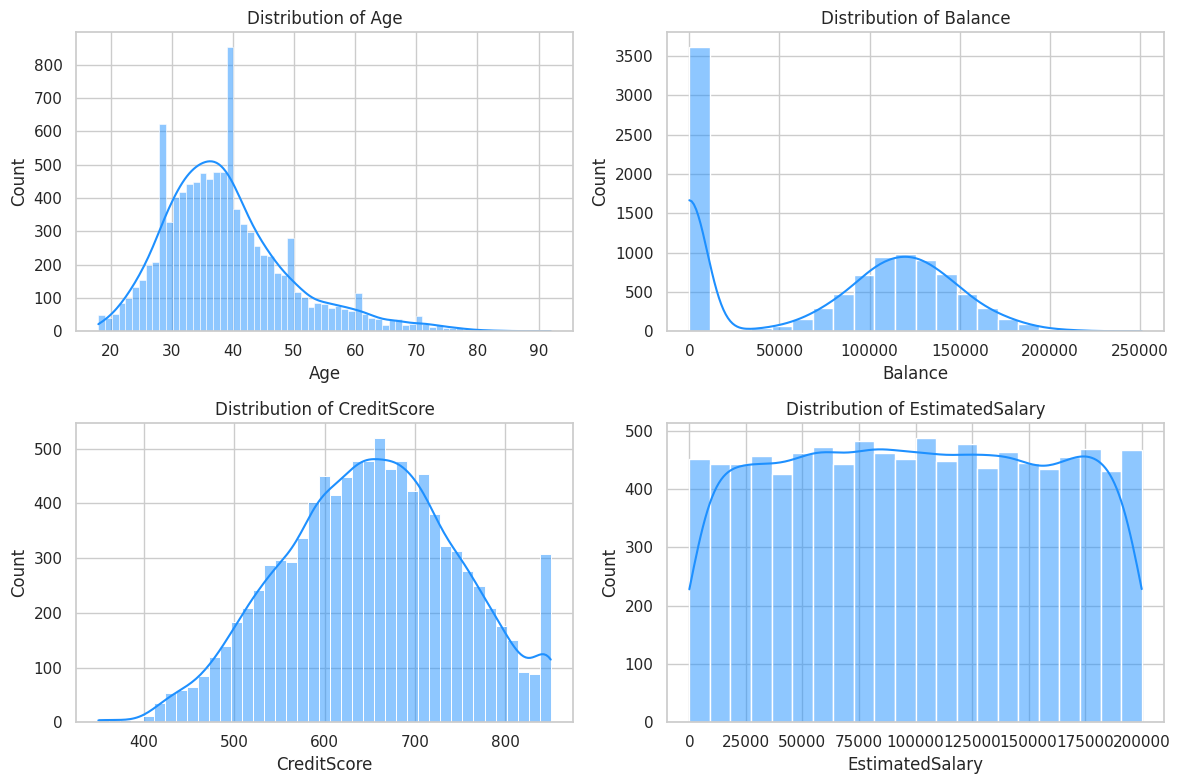

In [ ]:
continuous_features= ["Age", "Balance", "CreditScore", "EstimatedSalary"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, col in enumerate(continuous_features):
    sns.histplot(data=bank, x=col, kde=True, ax=axes[i], color='dodgerblue')
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

- Though the distribution of age shows a normal curve but we have peaks in two different age groups. One around 30 and the other around 40. So, the most costomers are young and mid-aged individuals.
- We can see that the estimated salary for is uniform across customer. So, salary may not be a reason for customers having zero balance in their account.
- While most of the customers' credit score lies in 600-700 range, the tail on the left in not very long. Hence we can say that the bank has a low-risk customer base.
- From the distribution of balace in the bank account we can say that most of the customers have zero balance in their account. This may be caused by two reasons. Either the customer is a teenager who might have newly opend their account, so their balance is zero, or they have a low salary, so they can't be able to keep much money in their account.

To uncover more patterns we need to check if the highest credit scores are for a specific income group or not. Also we have to check the relationship between balance vs age, and balance vs estimated salary to verify the above two causes of low balance.

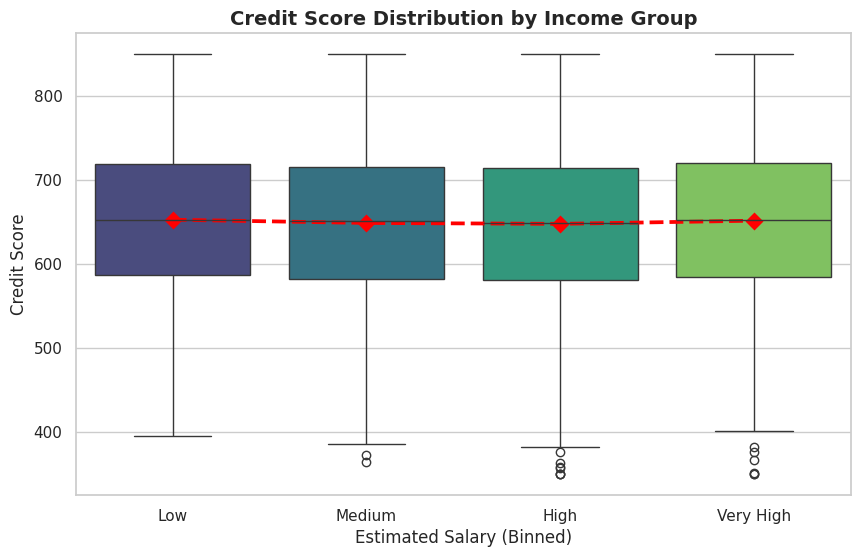

In [ ]:
bank['IncomeGroup'] = pd.qcut(bank['EstimatedSalary'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])

plt.figure(figsize=(10, 6))
sns.boxplot(data=bank, x='IncomeGroup', y='CreditScore', palette='viridis', hue='IncomeGroup', legend=False)
sns.pointplot(data=bank, x='IncomeGroup', y='CreditScore', color='red', markers='D', linestyles='--')

plt.title('Credit Score Distribution by Income Group', fontsize=14, fontweight='bold')
plt.xlabel('Estimated Salary (Binned)', fontsize=12)
plt.ylabel('Credit Score', fontsize=12)
plt.show()

We can see that regardless of income the credit score becomes same, which is a good sign.

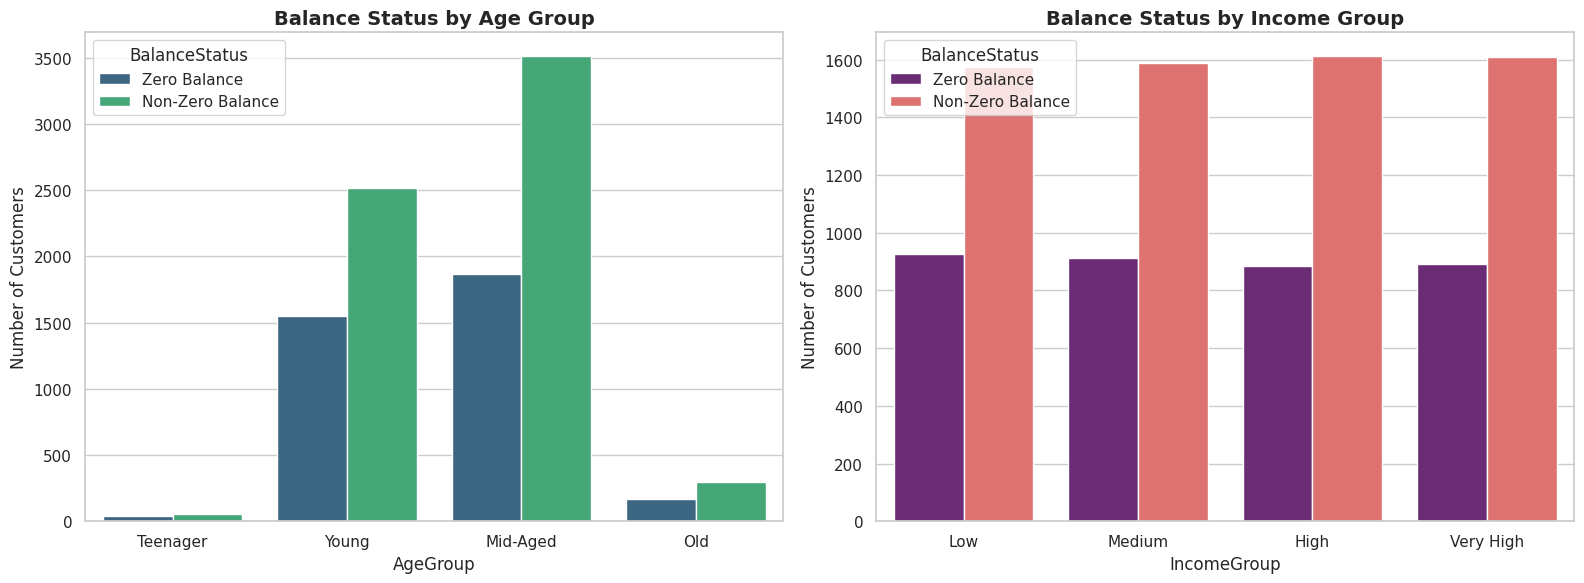

In [ ]:
bank['BalanceStatus'] = np.where(bank['Balance'] == 0, 'Zero Balance', 'Non-Zero Balance')

# Defined as: Teenager (<20), Young (20-35), Mid-Aged (35-60), Old (60+)
age_bins = [0, 20, 35, 60, 120]
age_labels = ['Teenager', 'Young', 'Mid-Aged', 'Old']
bank['AgeGroup'] = pd.cut(bank['Age'], bins=age_bins, labels=age_labels)

if 'IncomeGroup' not in bank.columns:
    bank['IncomeGroup'] = pd.qcut(bank['EstimatedSalary'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=bank, x='AgeGroup', hue='BalanceStatus', ax=axes[0], palette='viridis')
axes[0].set_title('Balance Status by Age Group', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Customers')

sns.countplot(data=bank, x='IncomeGroup', hue='BalanceStatus', ax=axes[1], palette='magma')
axes[1].set_title('Balance Status by Income Group', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Customers')

plt.tight_layout()
plt.show()


We can see that Salary is not an issue for zero balance. But from the Age vs Balance chart we can see that most zero balance accounts are of yound and mid-aged indivisuals, but these two age groups are expected to account for the majority of digital expenditure. That means this bank account may be used as a secondary or dormant account. So, these customers are most prone to churn.

The mid-aged group usually has the most credit needs, such as loans and insurance. If the zero balance, it means your bank is losing the "cross-sell" opportunity, which implies they are probably losing your profitable business to other banks while your account remains empty.

Let's cross chek this with the churn column. If the zero balance customers haven't left yet than they will be out main target to retain.

Churn Rate (%) by Balance Status:
BalanceStatus
Non-Zero Balance    24.079586
Zero Balance        13.823611
Name: Exited, dtype: float64


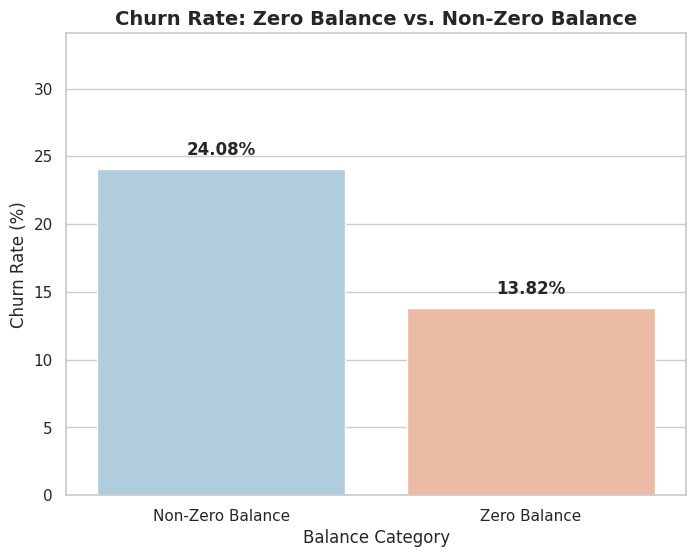

In [ ]:
churn_stats = bank.groupby('BalanceStatus')['Exited'].mean() * 100
print("Churn Rate (%) by Balance Status:")
print(churn_stats)

plt.figure(figsize=(8, 6))
sns.barplot(x=churn_stats.index, y=churn_stats.values, palette='RdBu_r')

plt.title('Churn Rate: Zero Balance vs. Non-Zero Balance', fontsize=14, fontweight='bold')
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.xlabel('Balance Category', fontsize=12)
plt.ylim(0, max(churn_stats.values) + 10)

for i, val in enumerate(churn_stats.values):
    plt.text(i, val + 1, f'{val:.2f}%', ha='center', fontweight='bold')

plt.show()


We can see that the churn rate is higher for the customers who have non-zero balance in their account, which is a major red flag. From this we can infer that the banks is lacking proper service or interest rates, so, even the funded customers are unhappy with the service.

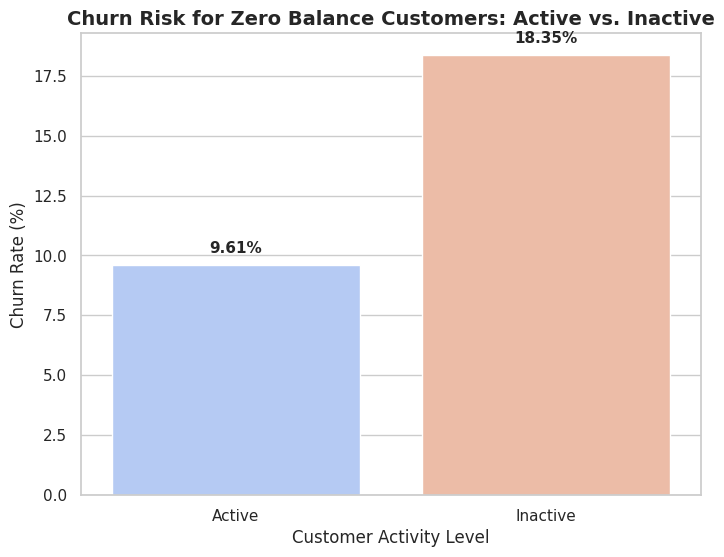

In [ ]:
zero_balance_customers = bank[bank['BalanceStatus'] == 'Zero Balance']
zero_balance_customers['MemberStatus'] = zero_balance_customers['IsActiveMember'].map({1: 'Active', 0: 'Inactive'})
activity_churn = zero_balance_customers.groupby('MemberStatus')['Exited'].mean() * 100

plt.figure(figsize=(8, 6))
sns.barplot(x=activity_churn.index, y=activity_churn.values, palette='coolwarm')

plt.title('Churn Risk for Zero Balance Customers: Active vs. Inactive', fontsize=14, fontweight='bold')
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.xlabel('Customer Activity Level', fontsize=12)

for i, val in enumerate(activity_churn.values):
    plt.text(i, val + 0.5, f'{val:.2f}%', ha='center', fontweight='bold', fontsize=11)

plt.show()

We can see that the churnt rate with this zero balance account is higher for inactive members. So, we can say that they are just waiting for the system to automatically close the account. And those who are active but have zero balance they are using this bank for specific service like a free credit card or some other benifit, while keeping their main welth elsewhere.

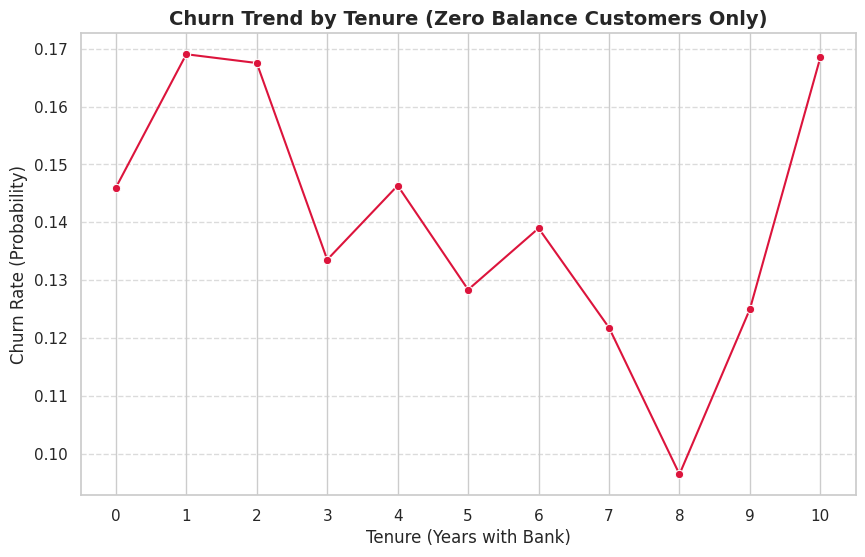

In [ ]:
zero_bal_df = bank[bank['BalanceStatus'] == 'Zero Balance']

plt.figure(figsize=(10, 6))

sns.lineplot(data=zero_bal_df, x='Tenure', y='Exited', marker='o', color='crimson', errorbar=None)

plt.title('Churn Trend by Tenure (Zero Balance Customers Only)', fontsize=14, fontweight='bold')
plt.xlabel('Tenure (Years with Bank)', fontsize=12)
plt.ylabel('Churn Rate (Probability)', fontsize=12)
plt.xticks(range(0, 11)) # Assuming tenure is 0-10 years
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


- The spike in 0-2 years says that customers opened their account and they didn't got satisfied with the service, or they might have opened it for a specific benifit or service, and when that specific benifit ended they lost interest in this bank.
- The spike in 10 years says that the most loyal customers are going elsewhere since the bank can't meet their expectations anymore due to some change in their lifestyle.

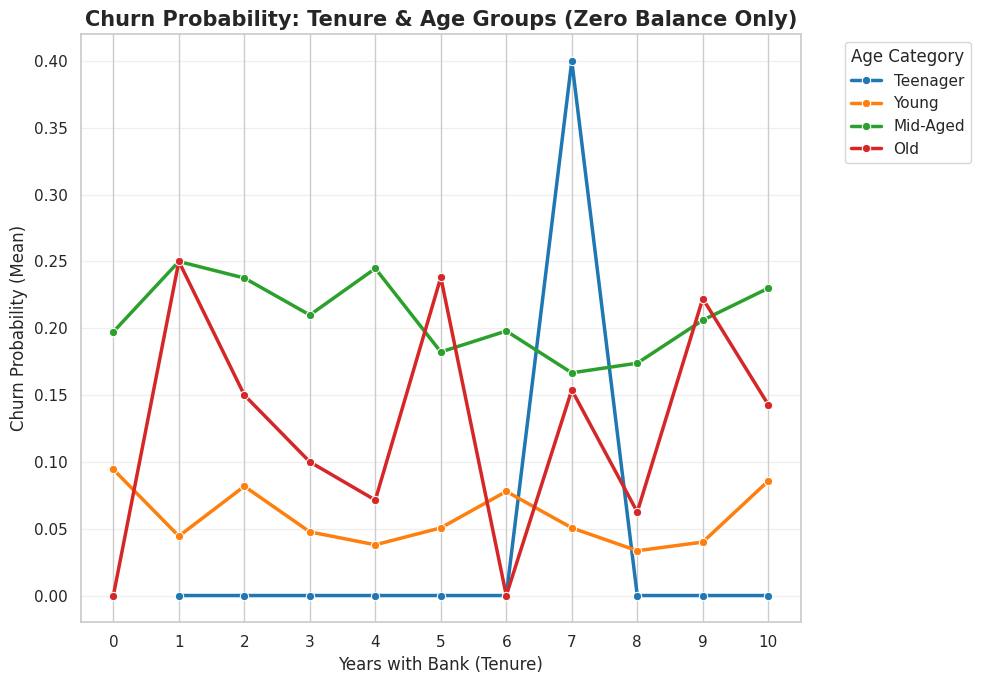

In [ ]:
plt.figure(figsize=(10, 7))

sns.lineplot(data=zero_bal_df, x='Tenure', y='Exited', hue='AgeGroup',
             marker='o', errorbar=None, palette='tab10', linewidth=2.5)

plt.title('Churn Probability: Tenure & Age Groups (Zero Balance Only)', fontsize=15, fontweight='bold')
plt.xlabel('Years with Bank (Tenure)', fontsize=12)
plt.ylabel('Churn Probability (Mean)', fontsize=12)
plt.legend(title='Age Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.xticks(range(0, 11))

plt.tight_layout()
plt.show()


The highest churn probability fro teenagers indicates a few things. This age group is tipically in their student life and might have opened their account for small purposes like scholarships etc. and since they don't have large payments like EMIs so changing thei bank is not much difficult. On the other hand in this age most of their dicisions are made by their parents, so there is a high chance that the churn among this age group is not by themselves.

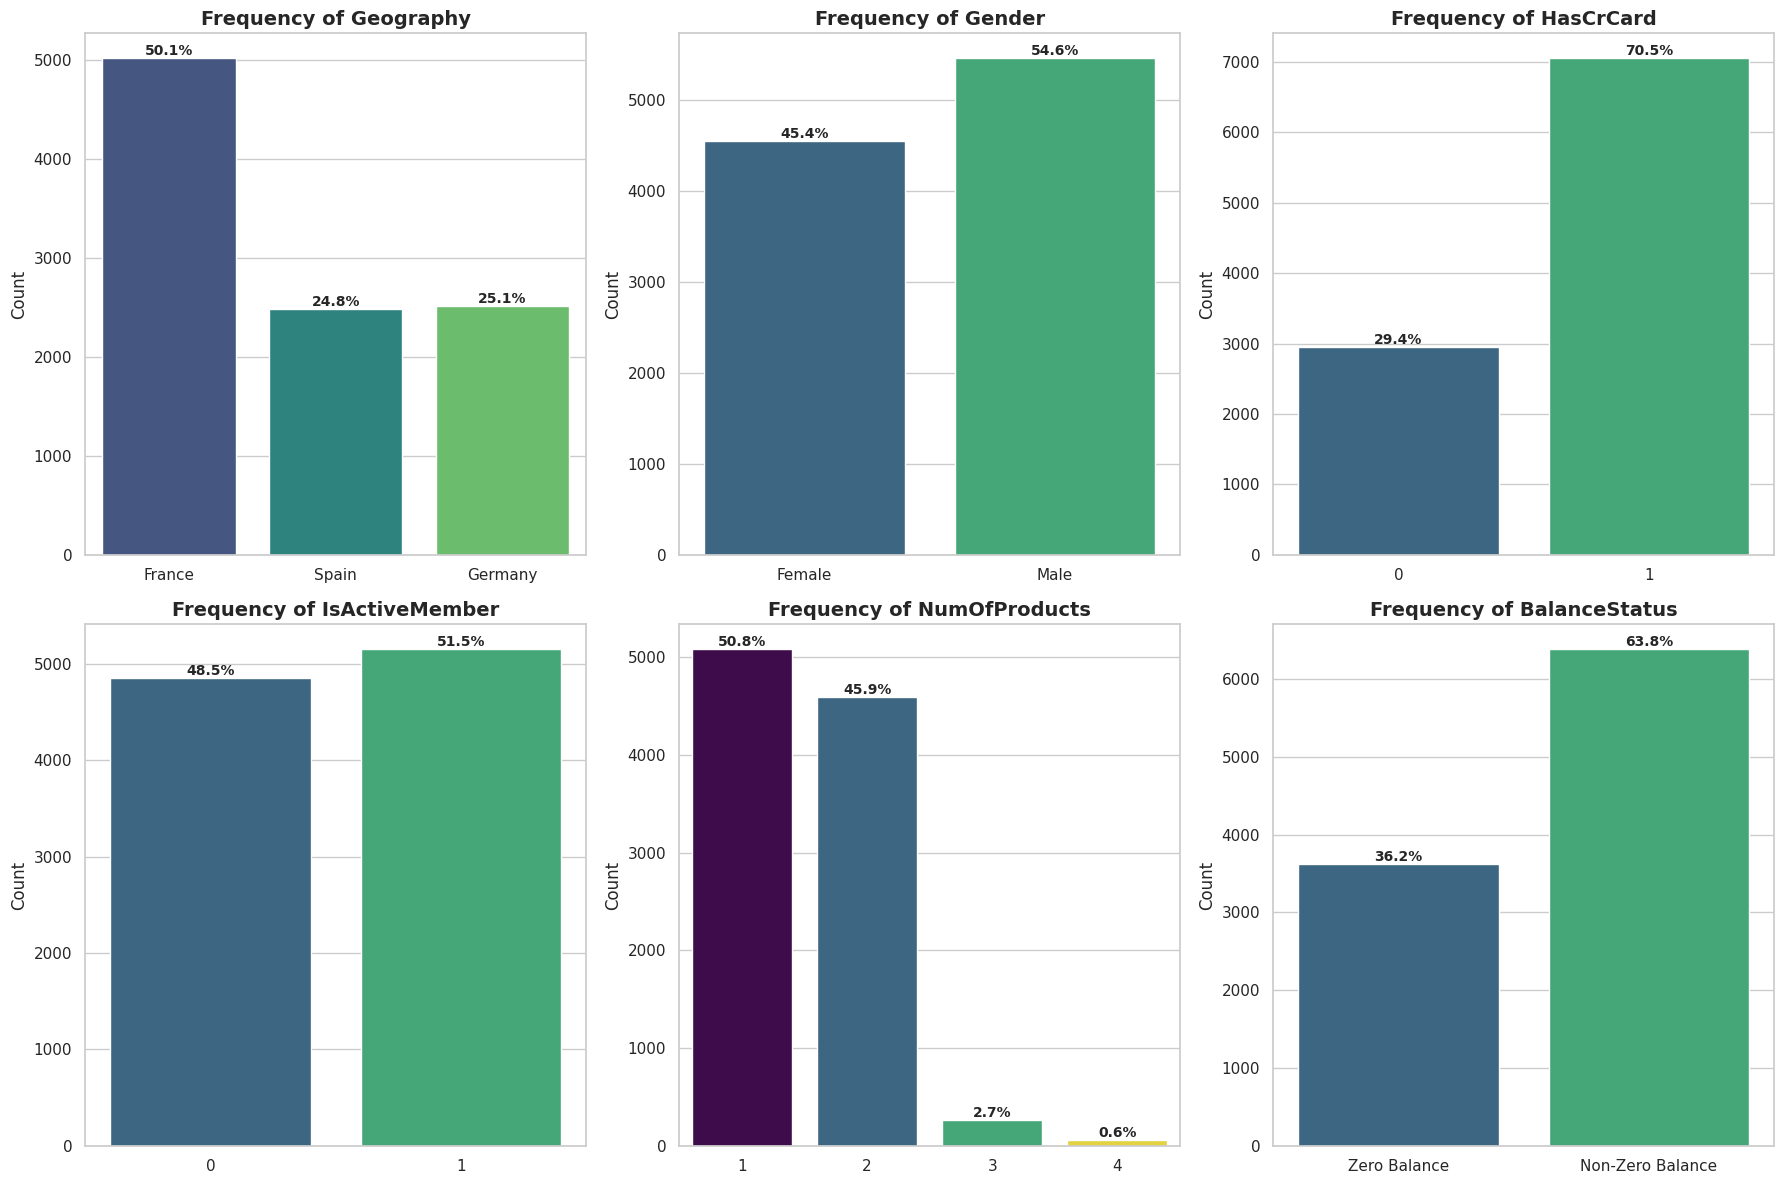

In [ ]:
cat_cols = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember', 'NumOfProducts', 'BalanceStatus']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=bank, x=col, ax=axes[i], palette='viridis', hue=col, legend=False)
    axes[i].set_title(f'Frequency of {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

    total = len(bank[col])
    for p in axes[i].patches:
        percentage = f'{100 * p.get_height() / total:.1f}%'
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        axes[i].annotate(percentage, (x, y), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

- The distribution of geography indicates that we have an class imbalance in the data. Since 50% data comes from only france and rest from the others, so the model might be biased. **So, we need to handle this class imbalance in feature engineering stage.**
- Most of the customers are taking only 1 or 2 services, while taking 3 or 4 services is rare. This indicates there is a high probabilty that the services don't meet customer expectations. So, they are only focusing on what is necessary.

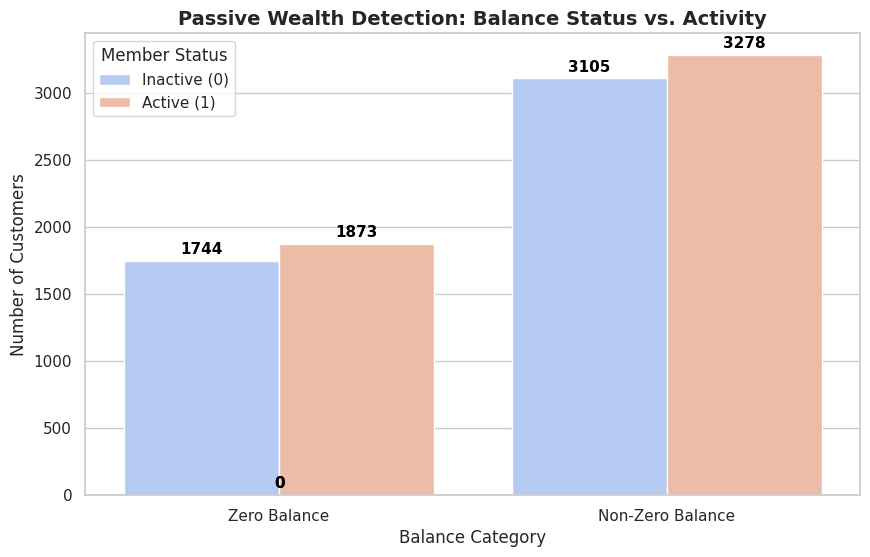

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=bank, x='BalanceStatus', hue='IsActiveMember', palette='coolwarm')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline',
                fontsize=11, fontweight='bold', color='black', xytext=(0, 5),
                textcoords='offset points')

plt.title('Passive Wealth Detection: Balance Status vs. Activity', fontsize=14, fontweight='bold')
plt.xlabel('Balance Category', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.legend(title='Member Status', labels=['Inactive (0)', 'Active (1)'])

plt.show()

- Above 3,000 inactive customers hold a balance but don't use your services. This group represents a high liquidity risk as they lack the daily habits that prevent switching to competitors.
- Above 1,500 active members currently hold zero balance. These are "power users" who already trust your platform; they are the primary targets for deposit-growth incentives.
- The near 1:1 ratio of active to inactive members in both categories suggests that holding a balance does not naturally drive engagement, indicating a need for better product "stickiness."
- Above 1,500 customers have no money and no activity. These accounts are likely "functionally churned" and should be deprioritized for marketing spend to optimize the budget.

In [ ]:
passive_wealth_segment = bank[(bank['Balance'] > 0) & (bank['IsActiveMember'] == 0)]
total_risk_value = passive_wealth_segment['Balance'].sum()
avg_passive_balance = passive_wealth_segment['Balance'].mean()
customer_count = len(passive_wealth_segment)

print(f"--- Passive Wealth Risk Report ---")
print(f"Total Customers at Risk: {customer_count:,}")
print(f"Total Monetary Value at Risk: ${total_risk_value:,.2f}")
print(f"Average Balance per Inactive Customer: ${avg_passive_balance:,.2f}")

--- Passive Wealth Risk Report ---
Total Customers at Risk: 3,105
Total Monetary Value at Risk: $374,024,593.41
Average Balance per Inactive Customer: $120,458.81


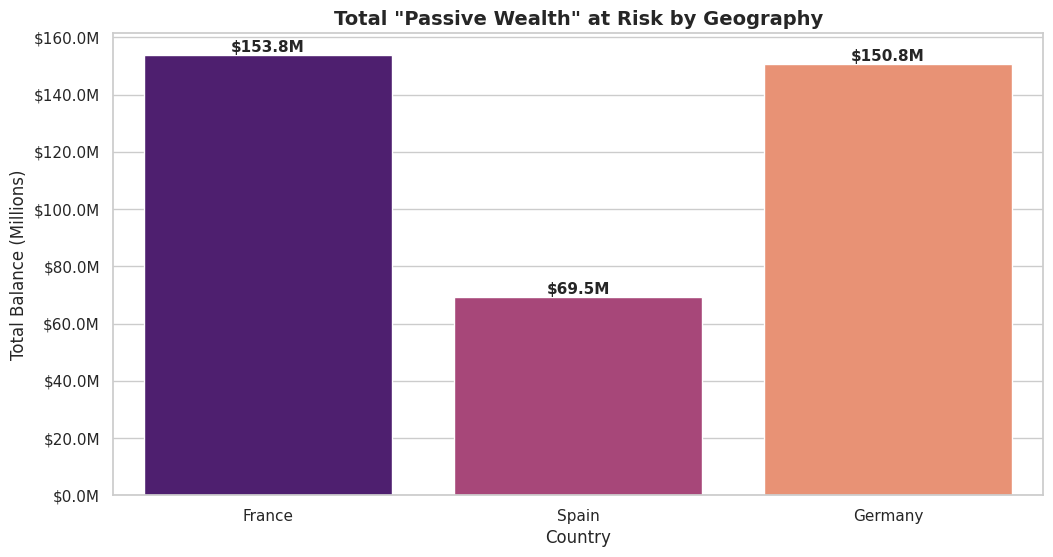

In [ ]:
passive_segment = bank[(bank['BalanceStatus'] == 'Non-Zero Balance') & (bank['IsActiveMember'] == 0)]

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=passive_segment, x='Geography', y='Balance',
                 estimator=sum, palette='magma', errorbar=None)

def millions(x, pos):
    return f'${x*1e-6:,.1f}M'


ax.yaxis.set_major_formatter(FuncFormatter(millions))

plt.title('Total "Passive Wealth" at Risk by Geography', fontsize=14, fontweight='bold')
plt.ylabel('Total Balance (Millions)', fontsize=12)
plt.xlabel('Country', fontsize=12)

for p in ax.patches:
    ax.annotate(f'${p.get_height()*1e-6:,.1f}M',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.show()


Since France has the highest customer count, so high passive welth risk is france is expected. But Germany has a much high passive wealth at risk compared to its customer count, which is a major red flag. Let's see which age group of those countries has the highest wealth at risk.

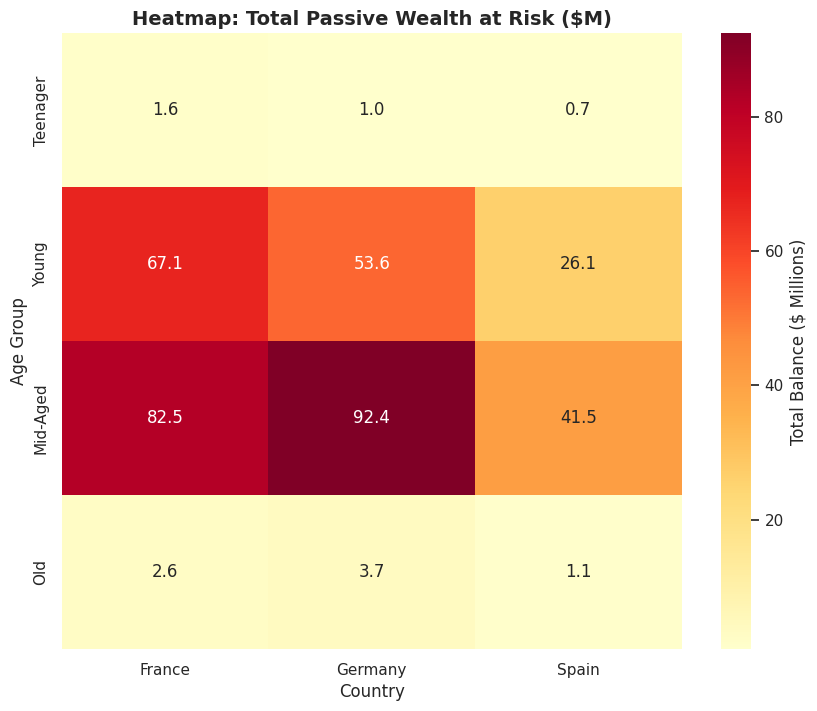

In [ ]:
passive_segment = bank[(bank['BalanceStatus'] == 'Non-Zero Balance') & (bank['IsActiveMember'] == 0)]
hazard_matrix = passive_segment.pivot_table(
    index='AgeGroup',
    columns='Geography',
    values='Balance',
    aggfunc='sum'
) / 1e6

plt.figure(figsize=(10, 8))
sns.heatmap(hazard_matrix, annot=True, fmt=".1f", cmap='YlOrRd', cbar_kws={'label': 'Total Balance ($ Millions)'})

plt.title('Heatmap: Total Passive Wealth at Risk ($M)', fontsize=14, fontweight='bold')
plt.xlabel('Country', fontsize=12)
plt.ylabel('Age Group', fontsize=12)
plt.show()


We can see that passive weath is at high risk for young and mid-aged customers which validates the previous inference that these two age groups are most prone to customer churn. So, we need more agressive re-engagement policy to retain customers from Germany.

From the frequency plot above we can see that 70% of the customers uses a credit card, indiacting that credint card has a major contribution to the banks overall revenue. But it also makes them prone to churn if they get more benifits from competetors. So, we have check how much of the cutomers who has credit card are active or inactive.

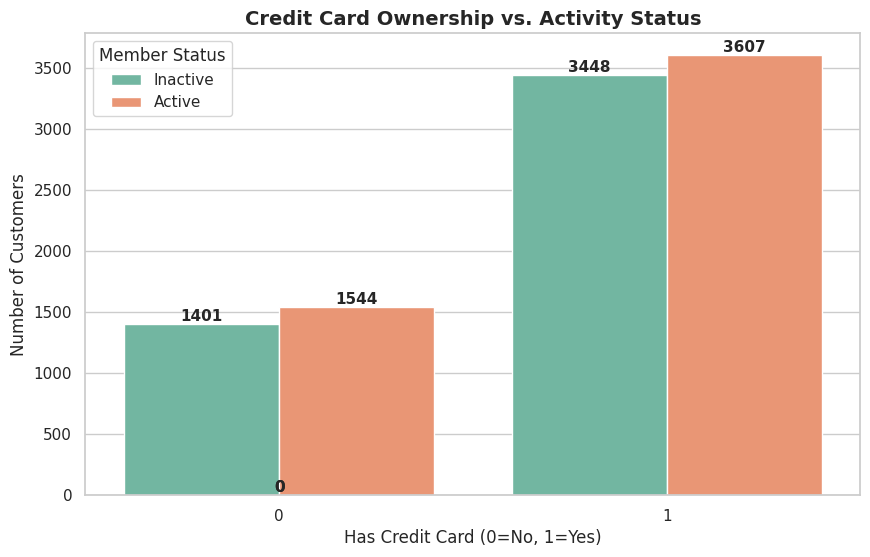

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=bank, x='HasCrCard', hue='IsActiveMember', palette='Set2')
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Credit Card Ownership vs. Activity Status', fontsize=14, fontweight='bold')
plt.xlabel('Has Credit Card (0=No, 1=Yes)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.legend(title='Member Status', labels=['Inactive', 'Active'])

plt.show()


- we can see that there is high count of inactive members who has credit card, which makes them prone to churn if a competetor affers more attractive rewards.
- Among non-cardholders, 1,500+ are active members. These are high-value, engaged customers who already use the bank's services and they are the primary targets for a "first credit card" cross-sell campaign.
- The ratio of active to inactive members is nearly identical (~51% active) whether they have a card or not. This suggests that owning a credit card does not automatically increase a customer's overall activity level with the bank.

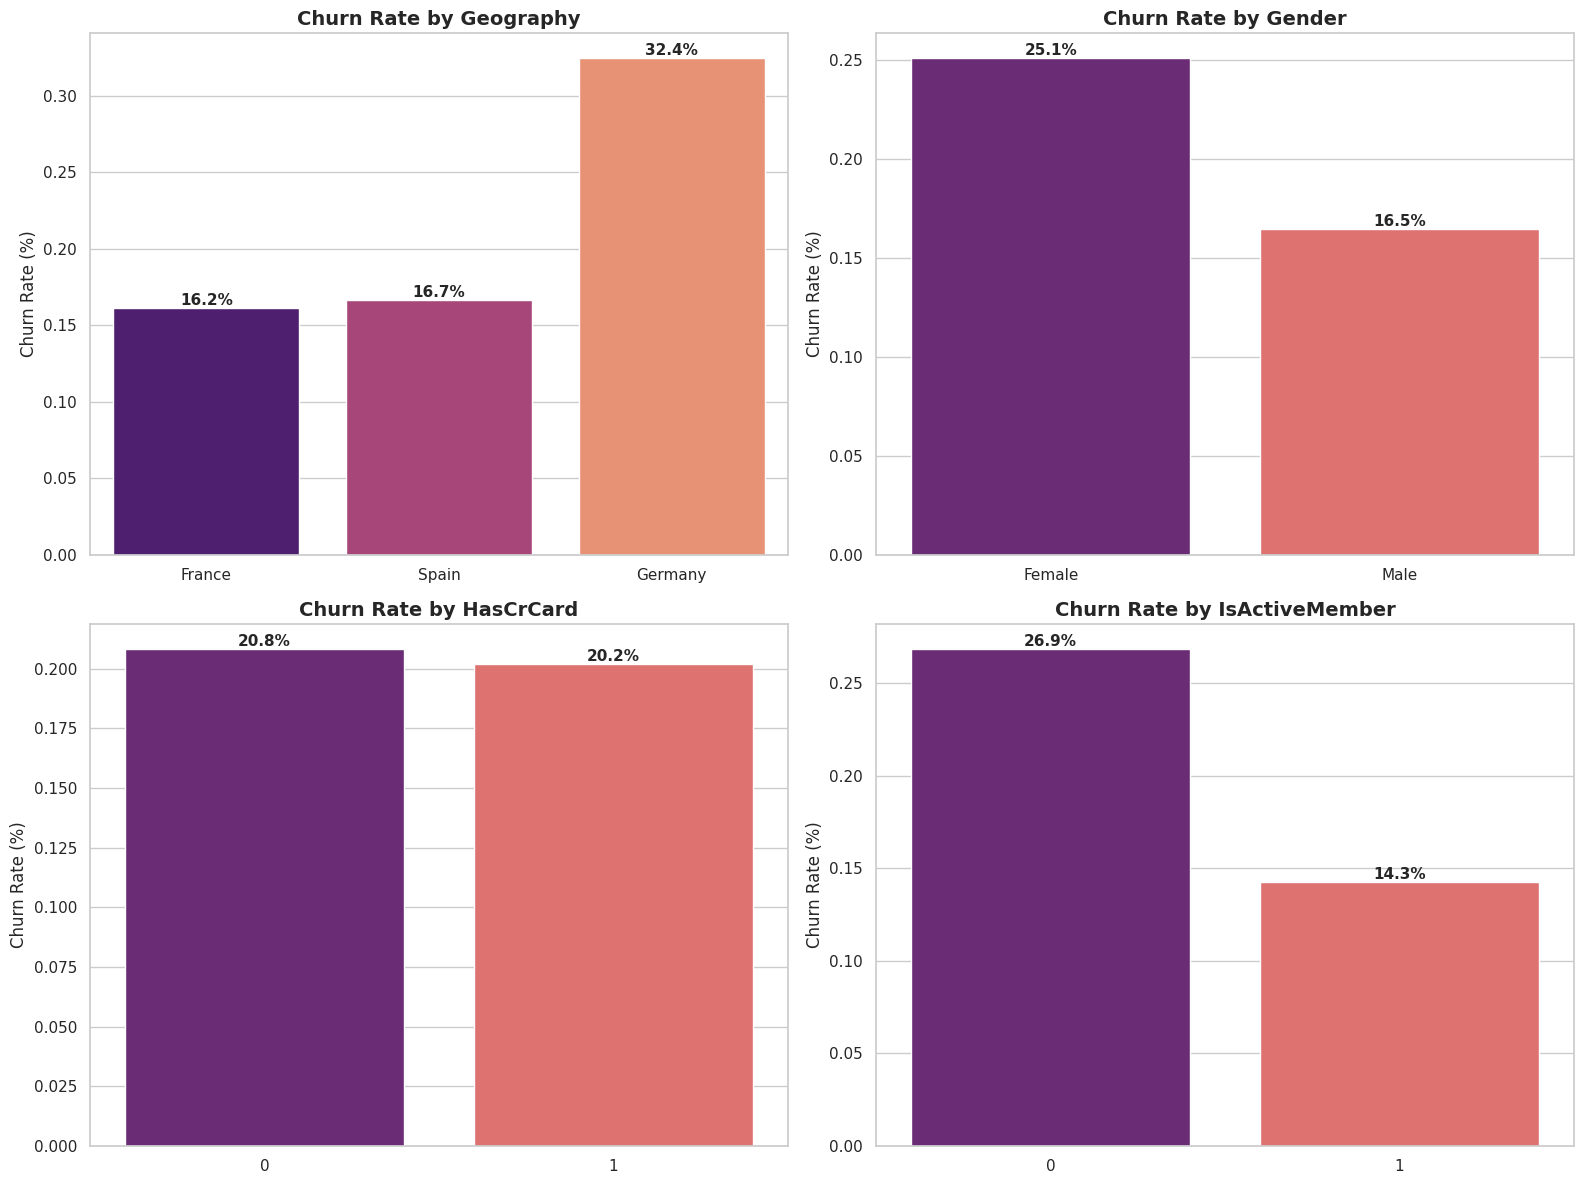

In [ ]:
risk_cols = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(risk_cols):
    ax = sns.barplot(data=bank, x=col, y='Exited', ax=axes[i], palette='magma', errorbar=None)
    for p in ax.patches:
        percentage = f'{100 * p.get_height():.1f}%'
        ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

    axes[i].set_title(f'Churn Rate by {col}', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

Previously we have seen how much passive wealth is at risk based on the geograpy and if the customer is an active member or not. This aove relationship with churn rates strenthens that.

## Complex Data Analysis (Multivariate & Feature Interactions)

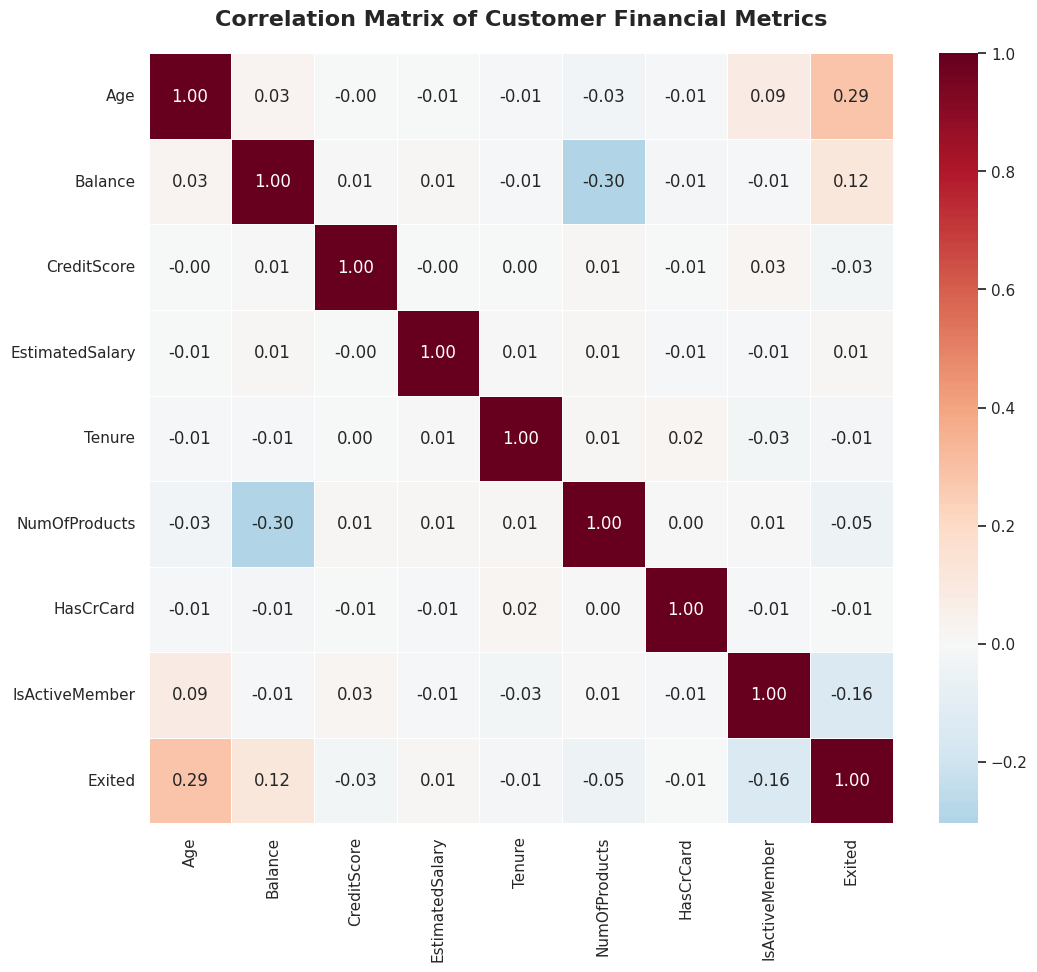

In [ ]:
numerical_features = bank[['Age', 'Balance', 'CreditScore', 'EstimatedSalary', 'Tenure', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'Exited']]

corr_matrix = numerical_features.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', fmt=".2f", linewidths=0.5, center=0)
plt.title('Correlation Matrix of Customer Financial Metrics', fontsize=16, fontweight='bold', pad=20)
plt.show()


- The main motivation behind this correlation chart is to look for if there are any multicollinearity among th features o not. But it looks like there is no redundant features and all of them are relevant contribution in making the prediction.
- There is very low correlation between bank balance and estimated salary, indicating that high salary doesn't implies high balance. So, the bank might not be used as a primary wealth storage.

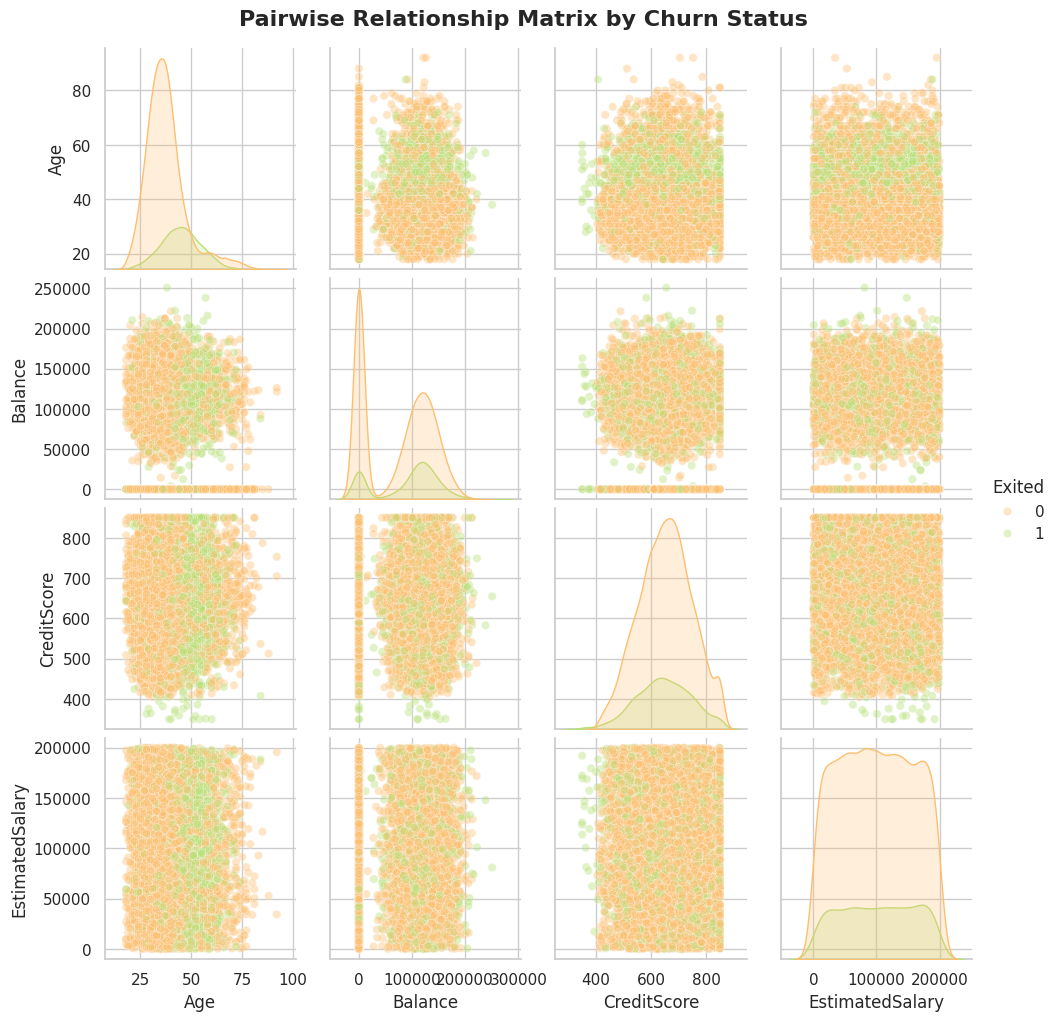

In [ ]:
cols_to_plot = ['Age', 'Balance', 'CreditScore', 'EstimatedSalary', 'Exited']
g = sns.pairplot(bank[cols_to_plot], hue='Exited', palette='RdYlGn',
                 diag_kind='kde', plot_kws={'alpha': 0.4})

g.fig.suptitle('Pairwise Relationship Matrix by Churn Status', y=1.02, fontsize=16, fontweight='bold')
plt.show()

- **Age-Related Churn Spike:** The graph indicates a higher probability of customer churn for people aged between 45 and 60. Offer a special program for people aged between 45 and 60 to focus on wealth management and retirement plan benefits.
- **Mid-Tier Balance Vulnerability:** The graph indicates a high density of customer churn for people with balances between $100k and $150k, irrespective of their credit scores. Offer special interest rate discounts for people with accounts greater than $100k. This will give a strong reason for people with high balances to remain with our bank.
- Salary Neutrality: The uniform distribution of scatter plots for Estimated Salary indicates that a customer's salary has no effect on their decision to churn. Change the marketing strategy from focusing on salary to focusing on behavior, specifically "IsActiveMember."
- Credit Score Indifference: The graph indicates a high rate of customer churn for people with all credit scores, including 700+. Monitor our competitors' premium card offers to ensure the rewards are attractive enough for high-credit-score customers to remain with the bank.

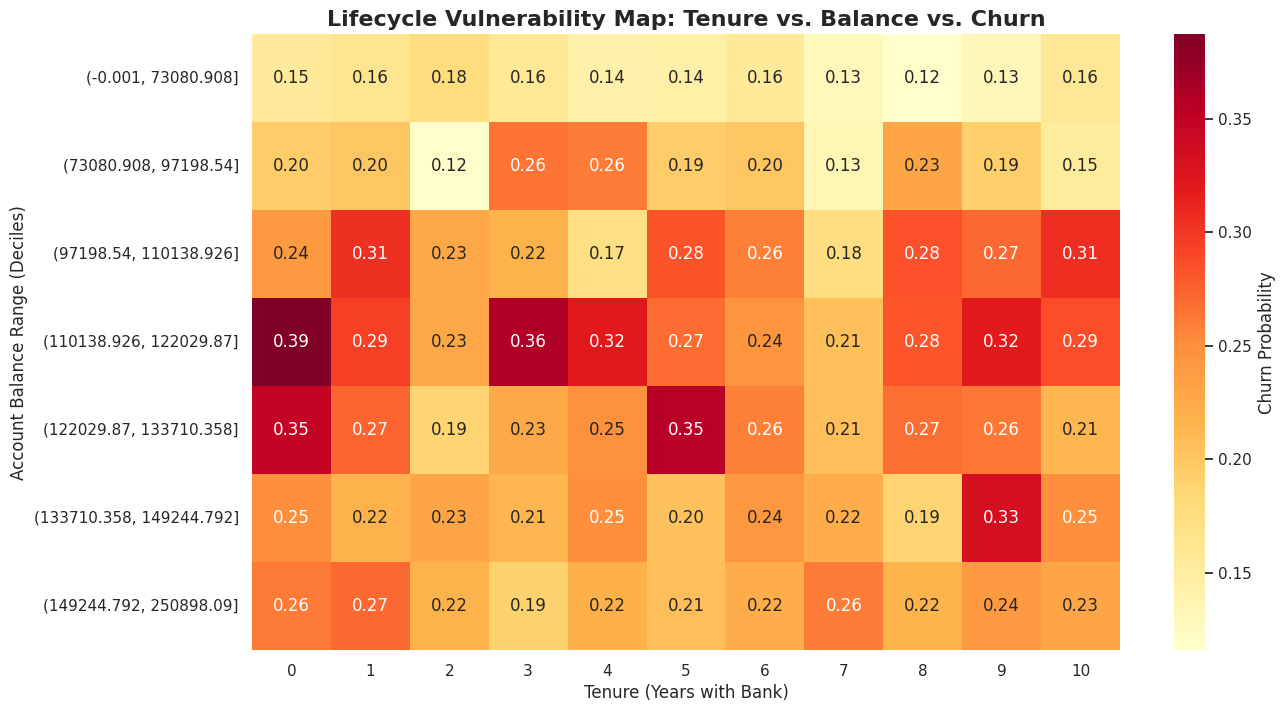

In [ ]:
bank['BalanceBin'] = pd.qcut(bank['Balance'], q=10, duplicates='drop')
risk_pivot = bank.pivot_table(index='BalanceBin', columns='Tenure', values='Exited', aggfunc='mean')

plt.figure(figsize=(14, 8))
sns.heatmap(risk_pivot, annot=True, fmt=".2f", cmap='YlOrRd', cbar_kws={'label': 'Churn Probability'})
plt.title('Lifecycle Vulnerability Map: Tenure vs. Balance vs. Churn', fontsize=16, fontweight='bold')
plt.xlabel('Tenure (Years with Bank)', fontsize=12)
plt.ylabel('Account Balance Range (Deciles)', fontsize=12)
plt.show()

The "Lifecycle Vulnerability Map" shows a "Danger Zone" where customers with balances between $110k and $133k are at a high risk of churn with a rate of 0.39 in the first year. This indicates that high-value acquisition is not translating into long-term value in the early lifecycle.
The bank could introduce a "Year One Loyalty Bonus" on accounts over $100k and "Priority Service Upgrades" at the 5-year point to prevent mid-tenure wealth migration.

## Fully targated data analysis

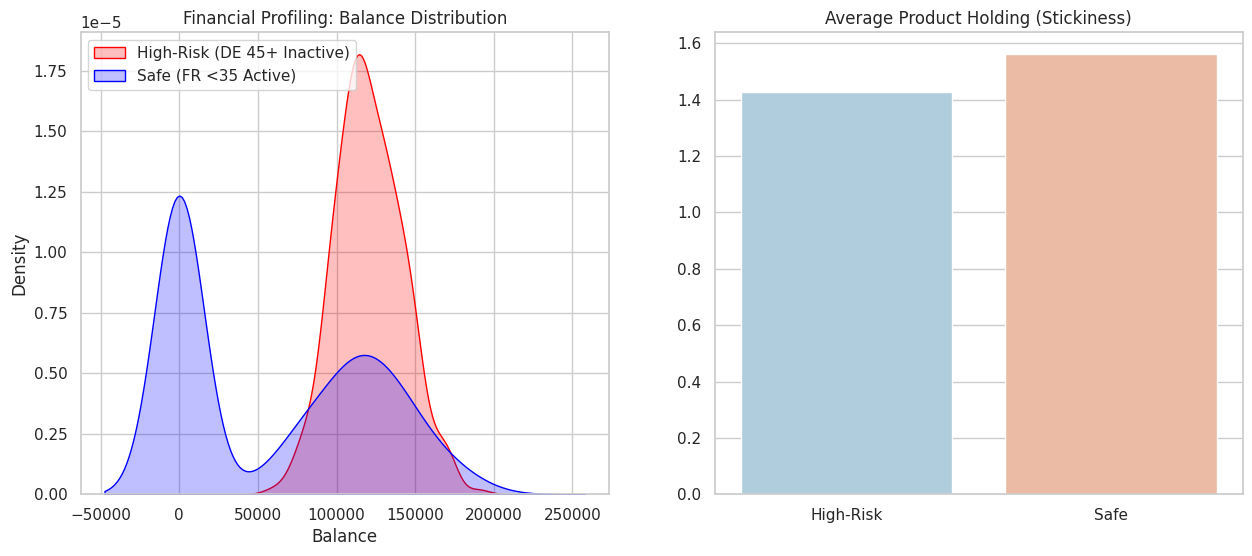

In [ ]:
high_risk = bank[(bank['Age'] > 45) & (bank['IsActiveMember'] == 0) & (bank['Geography'] == 'Germany')]
safe_group = bank[(bank['Age'] < 35) & (bank['IsActiveMember'] == 1) & (bank['Geography'] == 'France')]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.kdeplot(high_risk['Balance'], ax=axes[0], fill=True, color='red', label='High-Risk (DE 45+ Inactive)')
sns.kdeplot(safe_group['Balance'], ax=axes[0], fill=True, color='blue', label='Safe (FR <35 Active)')
axes[0].set_title('Financial Profiling: Balance Distribution')
axes[0].legend()

sns.barplot(x=['High-Risk', 'Safe'],
            y=[high_risk['NumOfProducts'].mean(), safe_group['NumOfProducts'].mean()],
            ax=axes[1], palette='RdBu_r')
axes[1].set_title('Average Product Holding (Stickiness)')
plt.show()

- **Concentrated Capital Risk**
Notice the high-risk group's high value and high concentration around the $125,000 balance peak, as opposed to the "safe" group's more distributed wealth. Prioritize this group's liquidity retention, as their exit represents a much larger capital outflow than any other group.

- **Passive 'Vault' Behavior**
Observe the many $0 balances within the "safe" group, who are Active, while the high-risk group possesses massive wealth but remains Inactive. Develop a "German Private Banking" strategy to convert these Passive clients to Active investors, thereby boosting their "stickiness."

- **The Stickiness Deficiency**
Compare the "safe" group's 1.56 products per user to the high-risk group's lower 1.42. Launch a "Multi-Product Loyalty Bonus" for the German account holders, as adding a second, complementary product can statistically reduce their flight risk.

- **Segmented Vulnerability**
The "safe" group exhibits "bimodal" characteristics, thriving at both the $0 and $125,000 balances, while the high-risk group relies exclusively on the high-balance segment. Do not assume high-balance clients are loyal clients. Engage the high-risk German segment with digital campaigns to develop the daily banking habit.


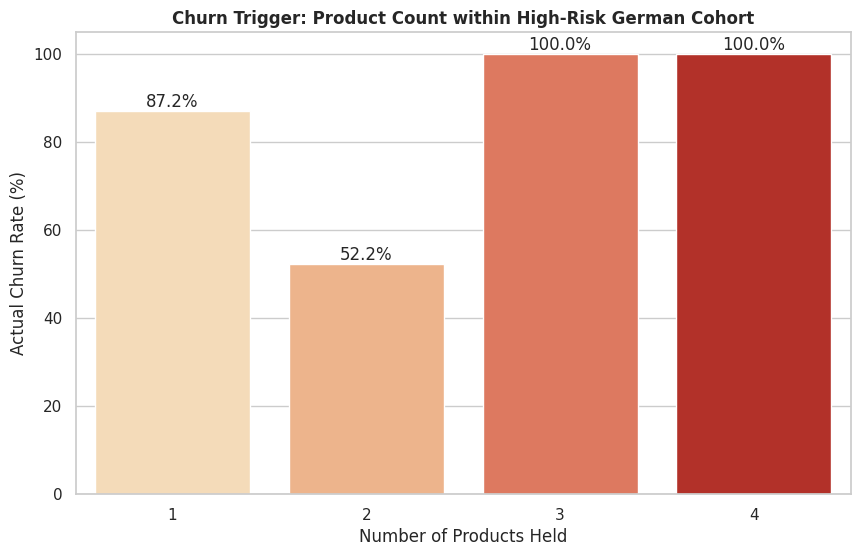

In [ ]:
plt.figure(figsize=(10, 6))
trigger_analysis = high_risk.groupby('NumOfProducts')['Exited'].mean() * 100

ax = sns.barplot(x=trigger_analysis.index, y=trigger_analysis.values, palette='OrRd')
plt.title('Churn Trigger: Product Count within High-Risk German Cohort', fontweight='bold')
plt.ylabel('Actual Churn Rate (%)')
plt.xlabel('Number of Products Held')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')
plt.show()


- **Critical Single Product Risk**
The customers with only one product have a massive 87.2% churn rate, which makes them the most volatile group of customers. Launch an immediate "Product Pairing" campaign targeting single-product German customers to increase customer commitment through secondary services.

- **The "Safety" Peak with 2 Products**
The sweet spot for this group of customers lies with exactly two products, which drastically reduces the customer churn rate to 52.2%. Target only this milestone of two products, as this is the peak of customer stability for this group of volatile customers.

- **Total Attrition with 3+ Products**
Ironically, any German customer in this volatile group with 3 or 4 products has a 100% customer churn rate. Inspect these specific accounts for "product dissatisfaction" or "hidden fees," as overwhelming them with too many products is causing them to totally abandon the service.

- **Localized Product Failure**
The massive customer churn rate with any number of products indicates that the current German product mix is failing to meet the needs of the 45+ demographic. Review your product mix in Germany to ensure your products, such as loans and credit cards, are competitive with other European Fintech services.


Based on the comprehensive Exploratory Data Analysis, here's an overall analysis, identification of vulnerable customer segments, proposed retention strategies, and feature engineering suggestions:

### Overall Analysis and Key Findings:

1.  **Balance & Activity:**
    *   A significant portion of customers hold zero balance, particularly young and mid-aged individuals, who are prone to churn.
    *   Counter-intuitively, non-zero balance customers exhibit a *higher* churn rate (24.08%) than zero-balance customers (13.82%), signaling underlying service dissatisfaction even among funded accounts.
    *   A substantial amount of "passive wealth" (approx. $374 million from 3,105 inactive customers) is at risk, particularly concentrated in Germany.
    *   The ratio of active to inactive members suggests that merely holding a balance or a credit card doesn't inherently drive engagement.

2.  **Geographic & Demographic Trends:**
    *   Germany stands out with the highest churn rate (32.4%) and a disproportionately high passive wealth risk, making it a critical region.
    *   Female customers show a higher churn rate (25.1%) compared to males (16.5%).
    *   Age-related churn spikes occur: "Teenagers" (zero-balance accounts), individuals aged 45-60, and young to mid-aged customers in Germany (for passive wealth).

3.  **Tenure & Product Usage:**
    *   Churn rates are elevated in the early (0-2 years) and very late (10 years) stages of customer tenure, suggesting issues with onboarding/initial satisfaction and long-term value retention.
    *   Most customers use only 1 or 2 products, indicating a potential lack of product "stickiness" or unmet expectations.
    *   For high-risk German customers, holding a single product is highly correlated with churn (87.2%), while surprisingly, holding 3 or 4 products also leads to 100% churn, pointing to product dissatisfaction or overwhelming complexity.

4.  **Financial Metrics:**
    *   Credit score and estimated salary generally show a neutral relationship with churn.
    *   Mid-tier balances ($100k-$150k) represent a "danger zone" with high churn density, especially in the first year of tenure.

### Vulnerable Customer Segments:

1.  **Inactive Customers with Non-Zero Balances:** Especially those in Germany, aged young to mid-aged, as they represent significant capital outflow risk.
2.  **High-Risk German Cohort (Age 45+, Inactive):**
    *   Those with **only one product** (87.2% churn).
    *   Those with **3 or 4 products** (100% churn).
3.  **New Customers (0-2 years tenure):** Particularly those with mid-tier balances ($110k-$133k).
4.  **Long-Term Loyal Customers (10 years tenure):** Indicating a failure to meet evolving needs.
5.  **Female Customers:** Showing a generally higher propensity to churn.
6.  **Teenagers with Zero-Balance Accounts:** High churn probability, likely due to specific, short-term account purposes.

### Proposed Retention Measures:

1.  **Targeted Re-engagement for Passive Wealth:**
    *   Implement a "German Private Banking" strategy to convert passive high-balance clients (especially in Germany) into active investors.
    *   Launch digital campaigns to encourage daily banking habits among inactive, high-balance German customers.
    *   Incentivize active members with zero balance to increase deposits (e.g., deposit-growth incentives).

2.  **Loyalty and Service Enhancement:**
    *   Introduce a "Year One Loyalty Bonus" for accounts over $100k (focus on the $110k-$133k balance range) to improve early-lifecycle retention.
    *   Offer "Priority Service Upgrades" at the 5-year tenure mark to retain mid-tenure customers.
    *   Provide special interest rate discounts for customers with balances exceeding $100k.

3.  **Product Strategy Optimization:**
    *   Execute an immediate "Product Pairing" campaign for single-product German customers to encourage a second product, aiming for the "sweet spot" of two products which significantly reduces churn.
    *   Thoroughly inspect accounts of high-risk German customers with 3+ products for "product dissatisfaction" or "hidden fees" and revise product offerings to avoid overwhelming customers.
    *   Review and localize product mix in Germany, ensuring competitiveness (e.g., loans, credit cards) for the 45+ demographic.

4.  **Personalized Outreach:**
    *   Develop special programs for the 45-60 age group focusing on wealth management and retirement planning benefits.
    *   Monitor competitor premium credit card offers to ensure attractive rewards for customers with high credit scores.
    *   Shift marketing strategy from focusing on estimated salary to customer behavior and active membership.

5.  **Resource Allocation:**
    *   Deprioritize marketing spend on "functionally churned" inactive customers with zero balance.

### Feature Engineering Ideas:

1.  **`TenureGroup`**: Categorize `Tenure` into distinct lifecycle stages (e.g., 'New Customer' (0-2 years), 'Developing Customer' (3-5 years), 'Established Customer' (6-9 years), 'Long-Term Loyal' (10+ years)) to capture tenure-specific churn behaviors.
2.  **`BalancePerProduct`**: Create a new feature by dividing `Balance` by `NumOfProducts` to understand the financial value each product holds for the customer.
3.  **`ProductVariety`**: A categorical feature indicating whether a customer holds 'Single Product', 'Two Products', or 'Multiple Products (3+)', especially for the German segment given its high churn rates.
4.  **`HighRiskGeography`**: A binary indicator for `Geography` (1 for Germany, 0 otherwise), given its distinct churn profile.
5.  **`AgeBalanceInteraction`**: An interaction term between `Age` and `Balance` to capture the specific vulnerability of young/mid-aged high-balance inactive customers.
6.  **`CreditCardEngagement`**: An interaction term between `HasCrCard` and `IsActiveMember` to identify distinct segments like 'Active Cardholders' or 'Inactive Cardholders'.
7.  **`EstimatedSalaryBucket`**: Create finer-grained buckets for `EstimatedSalary` if needed, although the current analysis suggests it's not a strong churn driver.
8.  **`ZeroBalanceAgeInteraction`**: An interaction between `BalanceStatus` ('Zero Balance') and `AgeGroup` ('Teenager', 'Young') to isolate specific churn drivers within this group.
9.  **`HasCreditCardAndInactive`**: A binary feature to specifically target inactive customers who possess a credit card.

These findings and recommendations provide a strong foundation for developing targeted churn prevention strategies and improving customer retention at the bank.